# Procedure for Adadetect

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, Subset, ConcatDataset, DataLoader, TensorDataset
from torchvision import datasets, transforms
from medmnist import ChestMNIST, DermaMNIST, BreastMNIST, BloodMNIST, OCTMNIST
from medmnist import INFO

from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from procedure import AdaDetectERM, AdaDetectDE

BASE_SEED = 42
def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_all_seeds(BASE_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


In [2]:
def get_images(dataset, indices):
    images = []
    for idx in indices:
        img, _ = dataset[idx]
        images.append(img)
    return torch.stack(images)


In [3]:
def get_fdp(ytrue, rejection_set):
    """
    """

    if rejection_set.size:
        fdp = np.sum(ytrue[rejection_set] == 0) / len(rejection_set)
        tdp = np.sum(ytrue[rejection_set] == 1) / np.sum(ytrue==1)
    else: 
        fdp=0
        tdp=0
    return fdp, tdp

## Create Classifiers

### Adadetect's CNN implementation

In [4]:
class BinaryConvNet(nn.Module):
    def __init__(self, in_channels):
        super(BinaryConvNet, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())
        
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


class ADACNNClassifier:
    def __init__(self, in_channels=1, epochs=10, lr=1e-3, batch_size=128, random_state=42):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.in_channels = in_channels
        self.model = BinaryConvNet(in_channels).to(device)
        self.random_state = random_state

        set_all_seeds(self.random_state)

    def fit(self, X, y):
        set_all_seeds(self.random_state)
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)
        

        generator = torch.Generator().manual_seed(self.random_state)

        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=True,
            generator=generator
        )

        opt = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.BCEWithLogitsLoss()

        self.model.train()
        for _ in range(self.epochs):
            for xb, yb in loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                yb = yb.unsqueeze(-1)

                opt.zero_grad()
                loss = loss_fn(self.model(xb), yb)
                loss.backward()
                opt.step()

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32)

        loader = torch.utils.data.DataLoader(X, batch_size=self.batch_size)

        self.model.eval()
        out = []

        with torch.no_grad():
            for xb in loader:
                xb = xb.to(device)
                proba_class_1 = nn.functional.sigmoid(self.model(xb)).cpu()
                proba_class_0 = 1 - proba_class_1
                # Return (N, 2) shape: [prob_class_0, prob_class_1]
                out.append(torch.cat([proba_class_0, proba_class_1], dim=1))

        return torch.cat(out).numpy()

### CNN

In [5]:
class CNNClassifier:
    def __init__(self, in_channels=1, epochs=10, lr=1e-3, batch_size=128, random_state=42):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.in_channels = in_channels
        self.random_state = random_state

        set_all_seeds(self.random_state)

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        ).to(device)

    def fit(self, X, y):
        set_all_seeds(self.random_state)
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)
        generator = torch.Generator().manual_seed(self.random_state)
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=True,
            generator=generator
        )

        opt = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.CrossEntropyLoss()

        self.model.train()
        for _ in range(self.epochs):
            for xb, yb in loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)

                opt.zero_grad()
                loss = loss_fn(self.model(xb), yb)
                loss.backward()
                opt.step()

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32)

        loader = torch.utils.data.DataLoader(X, batch_size=self.batch_size)

        self.model.eval()
        out = []

        with torch.no_grad():
            for xb in loader:
                xb = xb.to(device)
                out.append(torch.softmax(self.model(xb), dim=1).cpu())

        return torch.cat(out).numpy()

### RESNET

In [6]:
from email import generator


class ResNetClassifier:
    def __init__(self, in_channels=1, lr=1e-3, epochs=10, batch_size=128, random_state=42):
        self.in_channels = in_channels
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

        set_all_seeds(self.random_state)

        # ---- Load ResNet18 ----
        self.model = models.resnet18(weights=None)

        # ---- Replace first conv layer for arbitrary channels ----
        self.model.conv1 = nn.Conv2d(
            in_channels,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # ---- Replace classifier head for binary task ----
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)

        self.model = self.model.to(device)

    def fit(self, X, y):
        set_all_seeds(self.random_state)
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        generator = torch.Generator().manual_seed(self.random_state)

        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=True,
            generator=generator
        )

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.CrossEntropyLoss()

        self.model.train()

        for _ in range(self.epochs):
            for xb, yb in loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)

                optimizer.zero_grad()
                loss = loss_fn(self.model(xb), yb)
                loss.backward()
                optimizer.step()

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32)

        loader = torch.utils.data.DataLoader(X, batch_size=self.batch_size)

        self.model.eval()
        outs = []

        with torch.no_grad():
            for xb in loader:
                xb = xb.to(device)
                outs.append(torch.softmax(self.model(xb), dim=1).cpu())

        return torch.cat(outs).numpy()

### High res CNN for dog vs cat


In [7]:
# =========================================================
# CNN backbone (kept simple, used ONLY for features)
# =========================================================
class HRCNNClassifier:
    def __init__(self, in_channels=3, epochs=10, lr=1e-3, batch_size=128, random_state=42):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.in_channels = in_channels
        self.random_state = random_state

        set_all_seeds(self.random_state)

        # feature extractor (IMPORTANT: no reliance on logits)
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        ).to(device)

    # -------------------------
    # preprocessing
    # -------------------------
    def _prepare_tensor(self, X):
        if isinstance(X, np.ndarray):
            X = torch.from_numpy(X)

        X = X.float()
        if X.max() > 1:
            X = X / 255.0

        return X

    # -------------------------
    # optional training (not critical anymore)
    # -------------------------
    def fit(self, X, y=None):
        set_all_seeds(self.random_state)

        X = self._prepare_tensor(X)

        loader = torch.utils.data.DataLoader(
            X,
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=True
        )

        opt = optim.AdamW(self.model.parameters(), lr=self.lr)

        self.model.train()

        for epoch in range(self.epochs):
            total_loss = 0

            for xb in loader:
                xb = xb.to(device)

                feat = self.model(xb)

                # self-supervised stability loss (keeps representation stable)
                loss = torch.mean(feat ** 2)

                opt.zero_grad()
                loss.backward()
                opt.step()

                total_loss += loss.item()

            print(f"Epoch {epoch+1}/{self.epochs} | loss={total_loss:.4f}")

    # =========================================================
    # FEATURE EXTRACTION (critical part)
    # =========================================================
    def extract_features(self, X):
        X = self._prepare_tensor(X)

        loader = torch.utils.data.DataLoader(
            X,
            batch_size=self.batch_size,
            pin_memory=True
        )

        self.model.eval()

        feats = []

        with torch.no_grad():
            for xb in loader:
                xb = xb.to(device)
                feats.append(self.model(xb).cpu())

        return torch.cat(feats).numpy()

    # =========================================================
    # MAHALANOBIS SCORE (THIS FIXES YOUR PROBLEM)
    # =========================================================
    def fit_mahalanobis(self, xnull):
        feats = self.extract_features(xnull)

        self.mu = feats.mean(axis=0)

        Sigma = np.cov(feats, rowvar=False)

        # numerical stability (VERY important)
        Sigma += 1e-6 * np.eye(Sigma.shape[0])

        self.Sigma_inv = np.linalg.inv(Sigma)

    def decision_function(self, X):
        feats = self.extract_features(X)

        diff = feats - self.mu

        scores = np.einsum(
            'nd,dd,nd->n',
            diff,
            self.Sigma_inv,
            diff
        )

        return scores

    # optional (not used in AdaDetect)
    def predict_proba(self, X):
        return None

## Load Data

### MNIST

In [8]:
dataset_name = 'mnist'
train_data = datasets.MNIST(
    root = 'data',
    train=True,                         
    transform = transforms.ToTensor(), 
    download = True,            
)

inlr_labels=[4]
outlr_labels=[9]
print(train_data)
inlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(inlr_labels)).any(-1).nonzero(as_tuple=True)[0]
outlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(outlr_labels)).any(-1).nonzero(as_tuple=True)[0]

# Get the actual images instead of just indices
inlr = train_data.data[inlr_idx].float().numpy()/255.0
outlr = train_data.data[outlr_idx].float().numpy()/255.0

print(len(inlr), len(outlr))
print(inlr.shape, outlr.shape)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()
5842 5949
(5842, 28, 28) (5949, 28, 28)


C:\Users\h4sor\AppData\Local\Temp\ipykernel_29776\3962386305.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(inlr_labels)).any(-1).nonzero(as_tuple=True)[0]
C:\Users\h4sor\AppData\Local\Temp\ipykernel_29776\3962386305.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(outlr_labels)).any(-1).nonzero(as_tuple=True)[0]


### Fashion MNIST

Fashion MNIST Labels: 
0=T-shirt 1=Trouser, 2=Pullover, 3=Dress, 4=Coat (inlier), 5=Sandal, 6=Shirt, 7=Sneaker, 8=Bag, 9=Ankle boot (outlier)

In [ ]:
dataset_name = 'fashion_mnist'
train_data = datasets.FashionMNIST(
    root = 'data',
    train=True,                         
    transform = transforms.ToTensor(), 
    download = True,            
)


inlr_labels=[4] 
outlr_labels=[9] 
print(train_data)
inlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(inlr_labels)).any(-1).nonzero(as_tuple=True)[0]
outlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(outlr_labels)).any(-1).nonzero(as_tuple=True)[0]

# Get the actual images instead of just indices
inlr = train_data.data[inlr_idx].float().numpy()/255.0
outlr = train_data.data[outlr_idx].float().numpy()/255.0

print(len(inlr), len(outlr))
print(inlr.shape, outlr.shape)

### Chest MNIST

In [ ]:
dataset_name = 'ChestMNIST'
train_data = ChestMNIST(
    split='train',
    download=True,
    root='data',
    transform=transforms.ToTensor()
)
print(train_data)
targets = torch.tensor(train_data.labels)
inlr_idx = (targets.sum(dim=1) == 0).nonzero(as_tuple=True)[0]  # Healthy (no abnormalities)
outlr_idx = (targets.sum(dim=1) > 0).nonzero(as_tuple=True)[0]  # Sick (has abnormalities)
inlr= get_images(train_data, inlr_idx)
outlr = get_images(train_data, outlr_idx)
inlr = inlr.float().numpy()
outlr = outlr.float().numpy()
print(inlr[0])
print(len(inlr), len(outlr))

### Derma MNIST

In [ ]:
dataset_name = 'DermaMNIST'
train_data = DermaMNIST(split='train', download=True, root='data', transform=transforms.ToTensor())
test_data = DermaMNIST(split='test', download=True, root='data', transform=transforms.ToTensor())
val_data = DermaMNIST(split='val', download=True, root='data', transform=transforms.ToTensor())

# Extract and concatenate labels before merging datasets
train_labels = train_data.labels
test_labels = test_data.labels
val_labels = val_data.labels
all_labels = np.concatenate([train_labels, val_labels, test_labels])

# Merge datasets
train_data = ConcatDataset([train_data, val_data, test_data])

# Attach labels to the merged dataset
train_data.labels = all_labels

print(len(train_data),train_data[0][0].shape)


# DermaMNIST Skin Lesion Classification
# 0 → Actinic keratoses & intraepithelial carcinoma (Precancerous/early cancer)
# 1 → Basal cell carcinoma (Cancer)
# 2 → Benign keratosis-like lesions (Benign)
# 3 → Dermatofibroma (Benign)
# 4 → Melanoma (Dangerous/potentially fatal)
# 5 → Melanocytic nevi/moles (Usually benign)
# 6 → Vascular lesions (Benign)

targets_labels = train_data.labels.squeeze()  # Get label indices
benign_labels = [2, 3, 5, 6 ]  # Benign lesions
non_benign_labels = [0, 1, 4]  # Precancerous, cancer, dangerous

# Create indices for benign (inlr) and non-benign (outlr)
inlr_idx = np.where(np.isin(targets_labels, benign_labels))[0]  # Benign
outlr_idx = np.where(np.isin(targets_labels, non_benign_labels))[0]  # Non-benign/dangerous
inlr= get_images(train_data, inlr_idx)
outlr = get_images(train_data, outlr_idx)
print(len(inlr), len(outlr))
print(inlr[0])
plt.imshow(inlr[0].permute(1, 2, 0))

### OCTMNIST

In [ ]:
dataset_name = 'OCTMNIST'
train_data = OCTMNIST(split='train', download=True, root='data', transform=transforms.ToTensor())
test_data = OCTMNIST(split='test', download=True, root='data', transform=transforms.ToTensor())
val_data = OCTMNIST(split='val', download=True, root='data', transform=transforms.ToTensor())

# Extract and concatenate labels before merging datasets
train_labels = train_data.labels
test_labels = test_data.labels
val_labels = val_data.labels
all_labels = np.concatenate([train_labels, val_labels, test_labels])

# Merge datasets
train_data = ConcatDataset([train_data, val_data, test_data])

# Attach labels to the merged dataset
train_data.labels = all_labels
print(len(train_data), train_data[0][0].shape)

# OCTMNIST Ophthalmology Classification
# 0 → Choroidal neovascularization (Disease)
# 1 → Diabetic macular edema (Disease)
# 2 → Drusen (Disease)
# 3 → Normal (Healthy/inlier)

targets_labels = train_data.labels.squeeze()  # Get label indices
normal_labels = [3]  # Normal (healthy)
disease_labels = [0, 1, 2]  # Diseases (abnormal)

# Create indices for normal (inlr) and disease (outlr)
inlr_idx = np.where(np.isin(targets_labels, normal_labels))[0]  # Normal
outlr_idx = np.where(np.isin(targets_labels, disease_labels))[0]  # Diseases
inlr = get_images(train_data, inlr_idx)
outlr = get_images(train_data, outlr_idx)

print(f"Normal (inlr): {inlr.shape}, Disease (outlr): {outlr.shape}")
print(inlr[0])
plt.imshow(inlr[0].permute(1, 2, 0))
print(len(inlr), len(outlr))

### BloodMNIST

In [ ]:
dataset_name = 'BloodMNIST'
train_data = BloodMNIST(split='train', download=True, root='data', transform=transforms.ToTensor())
test_data = BloodMNIST(split='test', download=True, root='data', transform=transforms.ToTensor())
val_data = BloodMNIST(split='val', download=True, root='data', transform=transforms.ToTensor())

# Extract and concatenate labels before merging datasets
train_labels = train_data.labels
test_labels = test_data.labels
val_labels = val_data.labels
all_labels = np.concatenate([train_labels, val_labels, test_labels])

# Merge datasets
train_data = ConcatDataset([train_data, val_data, test_data])

# Attach labels to the merged dataset
train_data.labels = all_labels
print(len(train_data), train_data[0][0].shape)

# BloodMNIST Blood Cell Classification
# 0 → Basophil (Normal)
# 1 → Eosinophil (Normal)
# 2 → Erythroblast (Abnormal - immature RBC)
# 3 → Immature granulocytes (Abnormal - myelocytes, metamyelocytes, promyelocytes)
# 4 → Lymphocyte (Normal)
# 5 → Monocyte (Normal)
# 6 → Neutrophil (Normal)
# 7 → Platelet (Normal)

targets_labels = train_data.labels.squeeze()  # Get label indices
normal_labels = [0, 1, 4, 5, 6, 7]  # Normal blood cells
abnormal_labels = [2, 3]  # Abnormal/immature cells

# Create indices for normal (inlr) and abnormal (outlr)
inlr_idx = np.where(np.isin(targets_labels, normal_labels))[0]  # Normal
outlr_idx = np.where(np.isin(targets_labels, abnormal_labels))[0]  # Abnormal
inlr = get_images(train_data, inlr_idx)
outlr = get_images(train_data, outlr_idx)

print(f"Normal (inlr): {inlr.shape}, Abnormal (outlr): {outlr.shape}")
print(inlr[0])
plt.imshow(inlr[0].permute(1, 2, 0))

### Kaggle Dog vs Cat

In [8]:
import os
import urllib.request
import zipfile
from PIL import Image
dataset_name = 'DogsVsCats'
# Download dogs-vs-cats dataset
dataset_path = 'data/dogs_vs_cats'
os.makedirs(dataset_path, exist_ok=True)

zip_path = 'data/dogs_vs_cats.zip'
if not os.path.exists(zip_path):
    print("Downloading dogs-vs-cats dataset...")
    url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete!")
    
    # Extract dataset
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('data/')
    print("Extraction complete!")

# Load and prepare data
from pathlib import Path
import numpy as np

dogs_dir = Path('data/PetImages/Dog')
cats_dir = Path('data/PetImages/Cat')

# Load images
dogs_images = []
cats_images = []

for img_file in sorted(list(dogs_dir.glob('*.jpg'))[:6000]):  # Load first 6000
    try:
        img = Image.open(img_file).convert('RGB').resize((28, 28))
        dogs_images.append(np.array(img))
    except:
        pass

for img_file in sorted(list(cats_dir.glob('*.jpg'))[:6000]):  # Load first 6000
    try:
        img = Image.open(img_file).convert('RGB').resize((28, 28))
        cats_images.append(np.array(img))
    except:
        pass

# Convert to tensors
dogs_images = torch.tensor(np.array(dogs_images), dtype=torch.float32)
cats_images = torch.tensor(np.array(cats_images), dtype=torch.float32)

inlr = dogs_images.float().numpy()/255.0  # Dogs as normal class
outlr = cats_images.float().numpy()/255.0  # Cats as outlier class

print(f"Dogs: {inlr.shape}, Cats: {outlr.shape}")

Dogs: (5999, 28, 28, 3), Cats: (6000, 28, 28, 3)


In [9]:
print(inlr[0])

[[[0.52156866 0.5176471  0.5568628 ]
  [0.6039216  0.6039216  0.627451  ]
  [0.52156866 0.50980395 0.5686275 ]
  ...
  [0.64705884 0.6627451  0.7019608 ]
  [0.6156863  0.6313726  0.6784314 ]
  [0.56078434 0.5686275  0.6156863 ]]

 [[0.54509807 0.5372549  0.5803922 ]
  [0.6313726  0.6313726  0.6509804 ]
  [0.5411765  0.5294118  0.58431375]
  ...
  [0.68235296 0.69411767 0.7490196 ]
  [0.6509804  0.6627451  0.70980394]
  [0.5921569  0.60784316 0.6509804 ]]

 [[0.5568628  0.5529412  0.5921569 ]
  [0.6509804  0.654902   0.67058825]
  [0.5529412  0.54509807 0.59607846]
  ...
  [0.70980394 0.72156864 0.7764706 ]
  [0.6784314  0.68235296 0.7411765 ]
  [0.62352943 0.63529414 0.6784314 ]]

 ...

 [[0.30980393 0.31764707 0.36862746]
  [0.38431373 0.38039216 0.48235294]
  [0.43529412 0.41568628 0.5764706 ]
  ...
  [0.4627451  0.44313726 0.48235294]
  [0.30588236 0.32941177 0.36078432]
  [0.26666668 0.29411766 0.30980393]]

 [[0.47058824 0.44705883 0.67058825]
  [0.41960785 0.40784314 0.5803922 ]


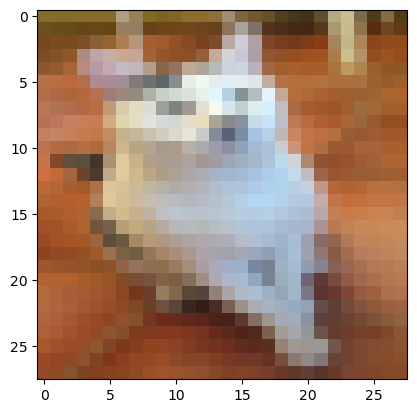

In [10]:
plt.imshow(outlr[129])

# Apply Procedure

## Parameters

In [11]:
m1 = 300
m0 = 700
test_idx = np.random.choice(len(inlr), replace=False, size=m0)
test0 = inlr[test_idx].numpy() if torch.is_tensor(inlr) else inlr[test_idx]
test1_idx = np.random.choice(len(outlr), replace=False, size=m1)
test1 = outlr[test1_idx].numpy() if torch.is_tensor(outlr) else outlr[test1_idx]
x = np.concatenate([test0, test1])

#NTS
n=4000

k = 3000
level=0.1

remaining_idx = np.setdiff1d(np.arange(len(inlr)), test_idx)
np.random.shuffle(remaining_idx)
remaining_idx = remaining_idx[:n]  # Take only first n samples to match mnist
xnull = inlr[remaining_idx].numpy() if torch.is_tensor(inlr) else inlr[remaining_idx]
#apply AdaDetect with ERM approach, with k=3000 (see notations of the paper)


## Apply

### Restructure data for different Classifiers

In [12]:
if dataset_name == 'mnist' or dataset_name == 'fashion_mnist':
    xnull_flatten = xnull.reshape(xnull.shape[0], -1)
    x_flatten = x.reshape(x.shape[0], -1)
  
    x_cnn = x.reshape(x.shape[0], 1, x.shape[1], x.shape[2])  # (1000, 1, 28, 28)
    xnull_cnn = xnull.reshape(xnull.shape[0], 1, xnull.shape[1], xnull.shape[2])
    
elif dataset_name == 'creditcard':
    xnull_flatten = xnull
    x_flatten = x


elif dataset_name == 'ChestMNIST' or dataset_name == "OCTMNIST":
    xnull_flatten = xnull.reshape(xnull.shape[0], -1)
    x_flatten = x.reshape(x.shape[0], -1)
    
    # ChestMNIST is already (batch, 1, 28, 28) from ToTensor()
    x_cnn = x 
    xnull_cnn = xnull 

elif dataset_name == 'DogsVsCats':
    xnull_flatten = xnull.reshape(xnull.shape[0], -1)
    x_flatten = x.reshape(x.shape[0], -1)
    
    # RGB images: (batch, 28, 28, 3) -> (batch, 3, 28, 28)
    x_cnn = x.permute(0, 3, 1, 2) if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
    xnull_cnn = xnull.permute(0, 3, 1, 2) if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32).permute(0, 3, 1, 2)

elif dataset_name == 'DermaMNIST' or dataset_name == 'BloodMNIST':
    xnull_flatten = xnull.reshape(xnull.shape[0], -1)
    x_flatten = x.reshape(x.shape[0], -1)
    
    # Data from DermaMNIST is already (batch, 3, 28, 28) from ToTensor()
    x_cnn = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
    xnull_cnn = xnull if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32)

true_labels = np.concatenate([np.zeros(m0), np.ones(m1)])


### ADACNN

In [ ]:

ACNN = ADACNNClassifier(in_channels=x_cnn.shape[1], epochs=10, lr=1e-3, batch_size=128)
proc = AdaDetectERM(scoring_fn = ACNN, split_size=k/n)
S_acnn = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set

fdp_acnn, tdp_acnn = get_fdp(true_labels, S_acnn)
print(f"ACNN - Rejections: {len(S_acnn)}, TDP: {tdp_acnn:.4f}, FDP: {fdp_acnn:.4f}")

### Randomforest

In [ ]:
rfc = RandomForestClassifier(max_depth=10)
proc = AdaDetectERM(scoring_fn = rfc, split_size=k/n) 
S_rf = proc.apply(x_flatten, level, xnull_flatten)#gives the rejection set 

fdp_rf, tdp_rf = get_fdp(true_labels, S_rf)
print(f"Random Forest - Rejections: {len(S_rf)}, TDP: {tdp_rf:.4f}, FDP: {fdp_rf:.4f}")

### CNN 

In [ ]:
cnn = CNNClassifier(in_channels=x_cnn.shape[1])

proc = AdaDetectERM(scoring_fn = cnn, split_size=k/n) 
S_cnn = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set

fdp_cnn, tdp_cnn = get_fdp(true_labels, S_cnn)
print(f"CNN - Rejections: {len(S_cnn)}, TDP: {tdp_cnn:.4f}, FDP: {fdp_cnn:.4f}")

### Resnet

In [13]:
rnn = ResNetClassifier(in_channels=x_cnn.shape[1])

proc = AdaDetectERM(scoring_fn = rnn, split_size=k/n)
S_resnet = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set


fdp_resnet, tdp_resnet = get_fdp(true_labels, S_resnet)
print(f"ResNet - Rejections: {len(S_resnet)}, TDP: {tdp_resnet:.4f}, FDP: {fdp_resnet:.4f}")

C:\Users\h4sor\AppData\Local\Temp\ipykernel_8356\4124284105.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)


ResNet - Rejections: 0, TDP: 0.0000, FDP: 0.0000


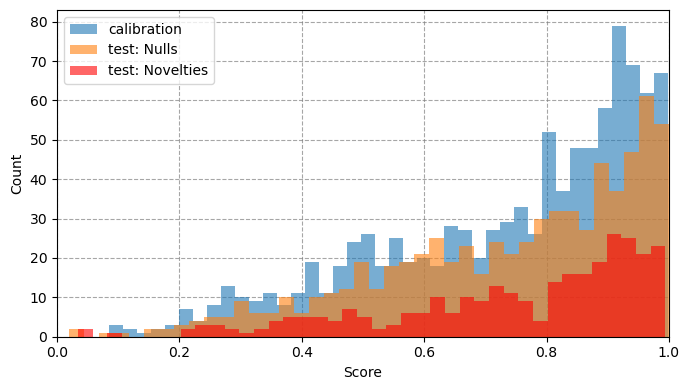

In [15]:
# Plot true null vs true novelty scores from AdaDetectERM
test_scores = proc.test_statistics
null_scores = test_scores[true_labels == 0]
novelty_scores = test_scores[true_labels == 1]
caleb = proc.null_statistics

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(caleb, bins=40, alpha=0.6, label="calibration")
ax.hist(null_scores, bins=40, alpha=0.6, label="test: Nulls")
ax.hist(novelty_scores, bins=40, alpha=0.6, label="test: Novelties", color='red')
ax.set_axisbelow(True)
ax.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_xlabel("Score")
ax.set_ylabel("Count")
# ax.set_title("Calibration vs test score distribution")
ax.set_xlim(0, 1)
ax.legend()

plt.tight_layout()
fig.savefig("cvd_score_histogram_RESNET18.pdf", bbox_inches="tight")
plt.show()

### MLP

In [ ]:
mlp = MLPClassifier(max_iter=300)
proc = AdaDetectERM(scoring_fn = mlp, split_size=k/n)
S_mlp = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set


fdp_mlp, tdp_mlp = get_fdp(true_labels, S_mlp)
print(f"MLP - Rejections: {len(S_mlp)}, TDP: {tdp_mlp:.4f}, FDP: {fdp_mlp:.4f}")

### Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
proc = AdaDetectERM(scoring_fn = lr, split_size=k/n) 
S_lr = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set


fdp_lr, tdp_lr = get_fdp(true_labels, S_lr)
print(f"Logistic Regression - Rejections: {len(S_lr)}, TDP: {tdp_lr:.4f}, FDP: {fdp_lr:.4f}")

### Adaboost

In [ ]:
ada = AdaBoostClassifier()
proc = AdaDetectERM(scoring_fn = ada, split_size=k/n)
S_adaB = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set


fdp_adaB, tdp_adaB = get_fdp(true_labels, S_adaB)
print(f"AdaBoost - Rejections: {len(S_adaB)}, TDP: {tdp_adaB:.4f}, FDP: {fdp_adaB:.4f}")

### PCA + Logistic Regression

In [ ]:
PCA_Log = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=0.8, svd_solver='full')),
    ("logistic", LogisticRegression(max_iter=5000, solver='lbfgs',random_state=42))
    ])

proc = AdaDetectERM(scoring_fn = PCA_Log, split_size=k/n)
S_pca_log = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set
fdp_pca_log, tdp_pca_log = get_fdp(true_labels, S_pca_log)
print(f"PCA + Logistic Regression - Rejections: {len(S_pca_log)}, TDP: {tdp_pca_log:.4f}, FDP: {fdp_pca_log:.4f}")



pca = proc.scoring_fn.named_steps['pca']
original_dim = pca.n_features_in_
reduced_dim = pca.n_components_
reduction = 1-(reduced_dim / original_dim)
print(f"original_dim: {original_dim}, reduced_dim: {reduced_dim}, reduction: {reduction:.4f}")

### Results Summary

In [ ]:
# Collect results from all classifiers
results = []

# ACNN
if 'S_acnn' in locals() and len(S_acnn) > 0:
    results.append(['ADACNN', len(S_acnn), tdp_acnn, fdp_acnn])
else:
    results.append(['ADACNN', 0, np.nan, np.nan])

# RandomForest
if 'S_rf' in locals() and len(S_rf) > 0:
    results.append(['RandomForest', len(S_rf), tdp_rf, fdp_rf])
else:
    results.append(['RandomForest', 0, np.nan, np.nan])

# CNN
if 'S_cnn' in locals() and len(S_cnn) > 0:
    results.append(['CNN', len(S_cnn), tdp_cnn, fdp_cnn])
else:
    results.append(['CNN', 0, np.nan, np.nan])

# ResNet
if 'S_resnet' in locals() and len(S_resnet) > 0:
    results.append(['ResNet', len(S_resnet), tdp_resnet, fdp_resnet])
else:
    results.append(['ResNet', 0, np.nan, np.nan])

# KNN
if 'S_knn' in locals() and len(S_knn) > 0:
    results.append(['KNN', len(S_knn), tdp_knn, fdp_knn])
else:
    results.append(['KNN', 0, np.nan, np.nan])

# MLP
if 'S_mlp' in locals() and len(S_mlp) > 0:
    results.append(['MLP', len(S_mlp), tdp_mlp, fdp_mlp])
else:
    results.append(['MLP', 0, np.nan, np.nan])

# Logistic Regression
if 'S_lr' in locals() and len(S_lr) > 0:
    results.append(['Logistic Regression', len(S_lr), tdp_lr, fdp_lr])
else:
    results.append(['Logistic Regression', 0, np.nan, np.nan])

# Decision Tree
if 'S_dt' in locals() and len(S_dt) > 0:
    results.append(['Decision Tree', len(S_dt), tdp_dt, fdp_dt])
else:
    results.append(['Decision Tree', 0, np.nan, np.nan])

# AdaBoost
if 'S_adaB' in locals() and len(S_adaB) > 0:
    results.append(['AdaBoost', len(S_adaB), tdp_adaB, fdp_adaB])
else:
    results.append(['AdaBoost', 0, np.nan, np.nan])

# PCA + Logistic Regression
if 'S_pca_log' in locals() and len(S_pca_log) > 0:
    results.append(['PCA + Logistic Regression', len(S_pca_log), tdp_pca_log, fdp_pca_log])
else:
    results.append(['PCA + Logistic Regression', 0, np.nan, np.nan])

# Create DataFrame and display
results_df = pd.DataFrame(results, columns=['Classifier', 'Rejections', 'TDP', 'FDP'])
print(results_df.to_string(index=False))

## 100 runs average


In [ ]:
m1 = 300
m0 = 700
n=4000

k = 3000
level=0.1
all_result = [0]*10


for i in range(10):
    seed = BASE_SEED + i
    set_all_seeds(seed)

    rng = np.random.default_rng(seed)


    test_idx = rng.choice(len(inlr), replace=False, size=m0)
    test0 = inlr[test_idx].numpy() if torch.is_tensor(inlr) else inlr[test_idx]
    test1_idx = rng.choice(len(outlr), replace=False, size=m1)
    test1 = outlr[test1_idx].numpy() if torch.is_tensor(outlr) else outlr[test1_idx]
    x = np.concatenate([test0, test1])
    remaining_idx = np.setdiff1d(np.arange(len(inlr)), test_idx)
    rng.shuffle(remaining_idx)
    remaining_idx = remaining_idx[:n]  # Take only first n samples to match mnist
    xnull = inlr[remaining_idx].numpy() if torch.is_tensor(inlr) else inlr[remaining_idx]
    true_labels = np.concatenate([np.zeros(m0), np.ones(m1)])


    if dataset_name == 'mnist' or dataset_name == 'fashion_mnist':
        xnull_flatten = xnull.reshape(xnull.shape[0], -1)
        x_flatten = x.reshape(x.shape[0], -1)
    
        x_cnn = x.reshape(x.shape[0], 1, x.shape[1], x.shape[2])  # (1000, 1, 28, 28)
        xnull_cnn = xnull.reshape(xnull.shape[0], 1, xnull.shape[1], xnull.shape[2])
        
    elif dataset_name == 'creditcard':
        xnull_flatten = xnull
        x_flatten = x


    elif dataset_name == 'ChestMNIST' or dataset_name == "OCTMNIST":
        xnull_flatten = xnull.reshape(xnull.shape[0], -1)
        x_flatten = x.reshape(x.shape[0], -1)
        
        # ChestMNIST is already (batch, 1, 28, 28) from ToTensor()
        x_cnn = x 
        xnull_cnn = xnull 

    elif dataset_name == 'DogsVsCats':
        xnull_flatten = xnull.reshape(xnull.shape[0], -1)
        x_flatten = x.reshape(x.shape[0], -1)
        
        # RGB images: (batch, 28, 28, 3) -> (batch, 3, 28, 28)
        x_cnn = x.permute(0, 3, 1, 2) if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
        xnull_cnn = xnull.permute(0, 3, 1, 2) if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32).permute(0, 3, 1, 2)

    elif dataset_name == 'DermaMNIST' or dataset_name == 'BloodMNIST':
        xnull_flatten = xnull.reshape(xnull.shape[0], -1)
        x_flatten = x.reshape(x.shape[0], -1)
        
        # Data from DermaMNIST is already (batch, 3, 28, 28) from ToTensor()
        x_cnn = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
        xnull_cnn = xnull if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32)
    
    # ACNN = ADACNNClassifier(in_channels=x_cnn.shape[1], epochs=10, lr=1e-3, batch_size=128)
    # proc = AdaDetectERM(scoring_fn = ACNN, split_size=k/n)
    # S_acnn = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set
    # fdp_acnn, tdp_acnn = get_fdp(true_labels, S_acnn)


    rfc = RandomForestClassifier(max_depth=10)
    proc = AdaDetectERM(scoring_fn = rfc, split_size=k/n)
    S_rf = proc.apply(x_flatten, level, xnull_flatten)#gives the rejection set
    fdp_rf, tdp_rf = get_fdp(true_labels, S_rf)

    # CNN = CNNClassifier(in_channels=x_cnn.shape[1])
    # proc = AdaDetectERM(scoring_fn = CNN, split_size=k/n)
    # S_cnn = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set
    # fdp_cnn, tdp_cnn = get_fdp(true_labels, S_cnn)

    # rnn = ResNetClassifier(in_channels=x_cnn.shape[1])
    # proc = AdaDetectERM(scoring_fn = rnn, split_size=k/n)
    # S_resnet = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set
    # fdp_resnet, tdp_resnet = get_fdp(true_labels, S_resnet)

    # knn = KNeighborsClassifier(4)
    # proc = AdaDetectERM(scoring_fn = knn, split_size=k/n)
    # S_knn = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set
    # fdp_knn, tdp_knn = get_fdp(true_labels, S_knn)

    # mlp = MLPClassifier(max_iter=300)
    # proc = AdaDetectERM(scoring_fn = mlp, split_size=k/n)
    # S_mlp = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set
    # fdp_mlp, tdp_mlp = get_fdp(true_labels, S_mlp)

    # lr = LogisticRegression(max_iter=1000)
    # proc = AdaDetectERM(scoring_fn = lr, split_size=k/n)
    # S_lr = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set
    # fdp_lr, tdp_lr = get_fdp(true_labels, S_lr)

    # dt = DecisionTreeClassifier(max_depth=10)
    # proc = AdaDetectERM(scoring_fn = dt, split_size=k/n)
    # S_dt = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set
    # fdp_dt, tdp_dt = get_fdp(true_labels, S_dt)

    ada = AdaBoostClassifier()
    proc = AdaDetectERM(scoring_fn = ada, split_size=k/n)
    S_adaB = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set
    fdp_adaB, tdp_adaB = get_fdp(true_labels, S_adaB)

    # PCA_Log = Pipeline([
    #     ("scale", StandardScaler()),
    #     ("pca", PCA(n_components=0.8, svd_solver='full')),
    #     ("logistic", LogisticRegression(max_iter=5000, solver='lbfgs',random_state=42))
    #     ])
    # proc = AdaDetectERM(scoring_fn = PCA_Log, split_size=k/n)
    # S_pca_log = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set
    # fdp_pca_log, tdp_pca_log = get_fdp(true_labels, S_pca_log)

    results = {
    # "ADACNN": {
    #     "rejections": len(S_acnn),
    #     "tdp": tdp_acnn,
    #     "fdp": fdp_acnn,
    #     "rejection_set": S_acnn,
    # },
    "RandomForest": {
        "rejections": len(S_rf),
        "tdp": tdp_rf,
        "fdp": fdp_rf,
        "rejection_set": S_rf,
    },
    # "CNN": {
    #     "rejections": len(S_cnn),
    #     "tdp": tdp_cnn,
    #     "fdp": fdp_cnn,
    #     "rejection_set": S_cnn,
    # },
    # "ResNet": {
    #     "rejections": len(S_resnet),
    #     "tdp": tdp_resnet,
    #     "fdp": fdp_resnet,
    #     "rejection_set": S_resnet,
    # },
    # "KNN": {
    #     "rejections": len(S_knn),
    #     "tdp": tdp_knn,
    #     "fdp": fdp_knn,
    #     "rejection_set": S_knn,
    # },
    # "MLP": {
    #     "rejections": len(S_mlp),
    #     "tdp": tdp_mlp,
    #     "fdp": fdp_mlp,
    #     "rejection_set": S_mlp,
    # },
    # "LogisticRegression": {
    #     "rejections": len(S_lr),
    #     "tdp": tdp_lr,
    #     "fdp": fdp_lr,
    #     "rejection_set": S_lr,
    # },
    # "DecisionTree": {
    #     "rejections": len(S_dt),
    #     "tdp": tdp_dt,
    #     "fdp": fdp_dt,
    #     "rejection_set": S_dt,
    # },
    "AdaBoost": {
        "rejections": len(S_adaB),
        "tdp": tdp_adaB,
        "fdp": fdp_adaB,
        "rejection_set": S_adaB,
    },
    # "PCA_Logistic": {
    #     "rejections": len(S_pca_log),
    #     "tdp": tdp_pca_log,
    #     "fdp": fdp_pca_log,
    #     "rejection_set": S_pca_log,
    # },
    }
    all_result[i] = results
    print(f"Run {i+1}/100 completed.")

summary_rows = []
classifier_names = sorted({name for run in all_result for name in run})
for clf_name in classifier_names:
    tdp_vals = [run[clf_name]["tdp"] for run in all_result if clf_name in run]
    fdp_vals = [run[clf_name]["fdp"] for run in all_result if clf_name in run]
    rej_vals = [run[clf_name]["rejections"] for run in all_result if clf_name in run]
    summary_rows.append([
        clf_name,
        np.mean(tdp_vals),
        np.var(tdp_vals),
        np.mean(fdp_vals),
        np.var(fdp_vals),
        np.mean(rej_vals),
        np.var(rej_vals),
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=[
        "Classifier",
        "TDP_mean",
        "TDP_var",
        "FDP_mean",
        "FDP_var",
        "Rejections_mean",
        "Rejections_var",
    ],
).sort_values("Classifier")
print(summary_df.to_string(index=False))

## Performance for 2d random gaussian noise that slowly diverge


In [ ]:
RNG = np.random.default_rng(0)

# parameters
n = 4000
m0 = 700
m1 = 300
m = m0 + m1
k = 3000
level = 0.1

two_sided = True
def get_fdp(ytrue, rejection_set):
    if rejection_set.size:
        fdp = np.sum(ytrue[rejection_set] == 0) / len(rejection_set)
        tdp = np.sum(ytrue[rejection_set] == 1) / np.sum(ytrue == 1)
    else:
        fdp = 0
        tdp = 0
    return fdp, tdp

def sample_2d_pu(two_sided=two_sided, other_mean=2.0):
    Y = RNG.normal(loc=[0.0, 0.0], scale=[1.0, 1.0], size=(n, 2))

    X_0 = RNG.normal(loc=[0.0, 0.0], scale=[1.0, 1.0], size=(m0, 2))
    if two_sided:
        mix = RNG.binomial(1, 0.5, size=m1)
        means = np.where(mix[:, None] == 1, [other_mean, other_mean], [-other_mean, -other_mean])
        X_1 = RNG.normal(loc=means, scale=[1.0, 1.0], size=(m1, 2))
    else:
        X_1 = RNG.normal(loc=[other_mean, other_mean], scale=[1.0, 1.0], size=(m1, 2))

    Z = np.vstack([Y, X_0, X_1])
    y_true = np.concatenate([
        np.zeros(n, dtype=int),
        np.zeros(m0, dtype=int),
        np.ones(m1, dtype=int)
    ])
    y_pu = np.concatenate([
        np.full(k, -1, dtype=int),
        np.ones(n + m - k, dtype=int)
    ])
    return Z, y_true, y_pu

def run_once_on_data(model, Z, y_true):
    xnull = Z[:n]
    x = Z[n:n+m]
    y_test_true = y_true[n:n+m]

    proc = AdaDetectERM(
        scoring_fn=model,
        split_size=k / n
    )

    rejection_set = proc.apply(x, level, xnull)
    return get_fdp(y_test_true, rejection_set), len(rejection_set)

step_size = 0.1
outlr_means = np.arange(0.0, 10.0 + step_size, step_size)
B = 10

fdp_logreg_means = []
tdp_logreg_means = []
fdp_nn_means = []
tdp_nn_means = []
fdp_rf_means = []
tdp_rf_means = []
fdp_ada_means = []
tdp_ada_means = []
fdp_pca_means = []
tdp_pca_means = []
fdp_logreg_stds = []
tdp_logreg_stds = []
fdp_nn_stds = []
tdp_nn_stds = []
fdp_rf_stds = []
tdp_rf_stds = []
fdp_ada_stds = []
tdp_ada_stds = []
fdp_pca_stds = []
tdp_pca_stds = []

for conv_mean in outlr_means:
    print(f"Running for outlier mean: {conv_mean:.2f}")
    fdps_logreg, tdps_logreg = [], []
    fdps_nn, tdps_nn = [], []
    fdps_rf, tdps_rf = [], []
    fdps_ada, tdps_ada = [], []
    fdps_pca, tdps_pca = [], []

    for b in range(B):
        Z, y_true, y_pu = sample_2d_pu(two_sided=two_sided, other_mean=conv_mean)

        (fdp, tdp), _ = run_once_on_data(
            LogisticRegression(max_iter=2000),
            Z, y_true
        )
        fdps_logreg.append(fdp)
        tdps_logreg.append(tdp)

        (fdp, tdp), _ = run_once_on_data(
            MLPClassifier(
                hidden_layer_sizes=(50, 50),
                activation="relu",
                max_iter=2000,
                random_state=b
            ),
            Z, y_true
        )
        fdps_nn.append(fdp)
        tdps_nn.append(tdp)

        (fdp, tdp), _ = run_once_on_data(
            RandomForestClassifier(n_estimators=300, max_depth=10, n_jobs=-1, random_state=b),
            Z, y_true
        )
        fdps_rf.append(fdp)
        tdps_rf.append(tdp)

        (fdp, tdp), _ = run_once_on_data(
            AdaBoostClassifier(random_state=b),
            Z, y_true
        )
        fdps_ada.append(fdp)
        tdps_ada.append(tdp)

        pca_log = Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=0.8, svd_solver="full")),
            ("logistic", LogisticRegression(max_iter=5000, solver="lbfgs", random_state=b)),
        ])
        (fdp, tdp), _ = run_once_on_data(
            pca_log,
            Z, y_true
        )
        fdps_pca.append(fdp)
        tdps_pca.append(tdp)

    fdp_logreg_means.append(np.mean(fdps_logreg))
    tdp_logreg_means.append(np.mean(tdps_logreg))
    fdp_nn_means.append(np.mean(fdps_nn))
    tdp_nn_means.append(np.mean(tdps_nn))
    fdp_rf_means.append(np.mean(fdps_rf))
    tdp_rf_means.append(np.mean(tdps_rf))
    fdp_ada_means.append(np.mean(fdps_ada))
    tdp_ada_means.append(np.mean(tdps_ada))
    fdp_pca_means.append(np.mean(fdps_pca))
    tdp_pca_means.append(np.mean(tdps_pca))
    fdp_logreg_stds.append(np.std(fdps_logreg))
    tdp_logreg_stds.append(np.std(tdps_logreg))
    fdp_nn_stds.append(np.std(fdps_nn))
    tdp_nn_stds.append(np.std(tdps_nn))
    fdp_rf_stds.append(np.std(fdps_rf))
    tdp_rf_stds.append(np.std(tdps_rf))
    fdp_ada_stds.append(np.std(fdps_ada))
    tdp_ada_stds.append(np.std(tdps_ada))
    fdp_pca_stds.append(np.std(fdps_pca))
    tdp_pca_stds.append(np.std(tdps_pca))
colors = {
    "ADACNN": "#d27df3",
    "CNN": "#ef553b",
    "ResNet": "#00cc96",
    "MLP": "#19d3f3",
    "LogisticRegression": "#636efa",
    "PCA_Logistic": "#ab63fa",
    "RandomForest": "#ffa15a",
    "AdaBoost": "#f3e419",
}

label_map = {
    "Logistic": "C1",
    "MLP": "C2",
    "ADACNN": "C3",
    "CNN": "C4",
    "ResNet": "C5",
    "PCA+Logistic": "C6",
    "PCA_Logistic": "C6",
    "RandomForest": "C7",
    "Random Forest": "C7",
    "AdaBoost": "C8",
}

output_dir = Path("pictures_for_monday")
output_dir.mkdir(parents=True, exist_ok=True)

fig, (ax_fdp, ax_tdp) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
ax_fdp.set_axisbelow(True)
ax_fdp.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

line_logreg_fdp = ax_fdp.plot(outlr_means, fdp_logreg_means, label=label_map["Logistic"], color=colors["LogisticRegression"])[0]
line_mlp_fdp = ax_fdp.plot(outlr_means, fdp_nn_means, label=label_map["MLP"], color=colors["MLP"])[0]
line_pca_fdp = ax_fdp.plot(outlr_means, fdp_pca_means, label=label_map["PCA+Logistic"], color=colors["PCA_Logistic"])[0]
line_rf_fdp = ax_fdp.plot(outlr_means, fdp_rf_means, label=label_map["RandomForest"], color=colors["RandomForest"])[0]
line_ada_fdp = ax_fdp.plot(outlr_means, fdp_ada_means, label=label_map["AdaBoost"], color=colors["AdaBoost"])[0]

# ax_fdp.fill_between(
#     outlr_means,
#     np.array(fdp_logreg_means) - np.array(fdp_logreg_stds),
#     np.array(fdp_logreg_means) + np.array(fdp_logreg_stds),
#     color=line_logreg_fdp.get_color(),
#     alpha=0.2,
#     linewidth=0,
#     zorder=1
#     )
# ax_fdp.fill_between(
#     outlr_means,
#     np.array(fdp_nn_means) - np.array(fdp_nn_stds),
#     np.array(fdp_nn_means) + np.array(fdp_nn_stds),
#     color=line_mlp_fdp.get_color(),
#     alpha=0.2,
#     linewidth=0,
#     zorder=1
#     )
ax_fdp.axhline(level, color="black", linestyle=":", linewidth=1)
ax_fdp.set_xlabel(r"$\delta$")
ax_fdp.set_ylabel(r"$\widehat{\text{FDR}}$")
ax_tdp.set_axisbelow(True)
ax_tdp.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax_fdp.legend(loc="upper left")

line_logreg_tdp = ax_tdp.plot(outlr_means, tdp_logreg_means, label=label_map["Logistic"], color=colors["LogisticRegression"])[0]
line_mlp_tdp = ax_tdp.plot(outlr_means, tdp_nn_means, label=label_map["MLP"], color=colors["MLP"])[0]
line_pca_tdp = ax_tdp.plot(outlr_means, tdp_pca_means, label=label_map["PCA+Logistic"], color=colors["PCA_Logistic"])[0]
line_rf_tdp = ax_tdp.plot(outlr_means, tdp_rf_means, label=label_map["RandomForest"], color=colors["RandomForest"])[0]

line_ada_tdp = ax_tdp.plot(outlr_means, tdp_ada_means, label=label_map["AdaBoost"], color=colors["AdaBoost"])[0]

# ax_tdp.fill_between(
#     outlr_means,
#     np.array(tdp_logreg_means) - np.array(tdp_logreg_stds),
#     np.array(tdp_logreg_means) + np.array(tdp_logreg_stds),
#     color=line_logreg_tdp.get_color(),
#     alpha=0.2,
#     linewidth=0,
#     zorder=1
#     )
# ax_tdp.fill_between(
#     outlr_means,
#     np.array(tdp_nn_means) - np.array(tdp_nn_stds),
#     np.array(tdp_nn_means) + np.array(tdp_nn_stds),
#     color=line_mlp_tdp.get_color(),
#     alpha=0.2,
#     linewidth=0,
#     zorder=1
#     )
ax_tdp.set_xlabel(r"$\delta$")
ax_tdp.set_ylabel(r"$\widehat{\text{TDR}}$")
ax_tdp.grid(True, linestyle="--", linewidth=0.7, color="gray", alpha=0.7)
fig.tight_layout()
fig_path = output_dir / "fdr_tdr_vs_outlier_mean.pdf"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to {fig_path}")

plt.show()

## Performance for 50d random gaussian noise that slowly diverge


In [ ]:
RNG = np.random.default_rng(0)

# parameters
n = 4000
m0 = 700
m1 = 300
m = m0 + m1
k = 3000
level = 0.1

two_sided = True
def get_fdp(ytrue, rejection_set):
    if rejection_set.size:
        fdp = np.sum(ytrue[rejection_set] == 0) / len(rejection_set)
        tdp = np.sum(ytrue[rejection_set] == 1) / np.sum(ytrue == 1)
    else:
        fdp = 0
        tdp = 0
    return fdp, tdp
d = 50  # dimension

def sample_50d_pu(two_sided=two_sided, other_mean=2.0):
    # unlabeled null data
    Y = RNG.normal(
        loc=np.zeros(d),
        scale=np.ones(d),
        size=(n, d)
    )

    # labeled nulls
    X_0 = RNG.normal(
        loc=np.zeros(d),
        scale=np.ones(d),
        size=(m0, d)
    )

    # labeled alternatives
    if two_sided:
        mix = RNG.binomial(1, 0.5, size=m1)

        positive_mean = np.full(d, other_mean)
        negative_mean = np.full(d, -other_mean)

        means = np.where(
            mix[:, None] == 1,
            positive_mean,
            negative_mean
        )

        X_1 = RNG.normal(
            loc=means,
            scale=np.ones(d),
            size=(m1, d)
        )
    else:
        X_1 = RNG.normal(
            loc=np.full(d, other_mean),
            scale=np.ones(d),
            size=(m1, d)
        )

    Z = np.vstack([Y, X_0, X_1])

    y_true = np.concatenate([
        np.zeros(n, dtype=int),
        np.zeros(m0, dtype=int),
        np.ones(m1, dtype=int)
    ])

    y_pu = np.concatenate([
        np.full(k, -1, dtype=int),
        np.ones(n + m - k, dtype=int)
    ])

    return Z, y_true, y_pu

def run_once_on_data(model, Z, y_true):
    xnull = Z[:n]
    x = Z[n:n+m]
    y_test_true = y_true[n:n+m]

    proc = AdaDetectERM(
        scoring_fn=model,
        split_size=k / n
    )

    rejection_set = proc.apply(x, level, xnull)
    return get_fdp(y_test_true, rejection_set), len(rejection_set)

step_size = 0.1
outlr_means = np.arange(0.0, 10.0 + step_size, step_size)
B = 10

fdp_logreg_means = []
tdp_logreg_means = []
fdp_nn_means = []
tdp_nn_means = []
fdp_rf_means = []
tdp_rf_means = []
fdp_ada_means = []
tdp_ada_means = []
fdp_pca_means = []
tdp_pca_means = []
fdp_logreg_stds = []
tdp_logreg_stds = []
fdp_nn_stds = []
tdp_nn_stds = []
fdp_rf_stds = []
tdp_rf_stds = []
fdp_ada_stds = []
tdp_ada_stds = []
fdp_pca_stds = []
tdp_pca_stds = []

for conv_mean in outlr_means:
    print(f"Running for outlier mean: {conv_mean:.2f}")
    fdps_logreg, tdps_logreg = [], []
    fdps_nn, tdps_nn = [], []
    fdps_rf, tdps_rf = [], []
    fdps_ada, tdps_ada = [], []
    fdps_pca, tdps_pca = [], []

    for b in range(B):
        Z, y_true, y_pu = sample_50d_pu(two_sided=two_sided, other_mean=conv_mean)

        (fdp, tdp), _ = run_once_on_data(
            LogisticRegression(max_iter=2000),
            Z, y_true
        )
        fdps_logreg.append(fdp)
        tdps_logreg.append(tdp)

        (fdp, tdp), _ = run_once_on_data(
            MLPClassifier(
                hidden_layer_sizes=(50, 50),
                activation="relu",
                max_iter=2000,
                random_state=b
            ),
            Z, y_true
        )
        fdps_nn.append(fdp)
        tdps_nn.append(tdp)

        (fdp, tdp), _ = run_once_on_data(
            RandomForestClassifier(n_estimators=300, max_depth=10, n_jobs=-1, random_state=b),
            Z, y_true
        )
        fdps_rf.append(fdp)
        tdps_rf.append(tdp)

        (fdp, tdp), _ = run_once_on_data(
            AdaBoostClassifier(random_state=b),
            Z, y_true
        )
        fdps_ada.append(fdp)
        tdps_ada.append(tdp)

        pca_log = Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=0.8, svd_solver="full")),
            ("logistic", LogisticRegression(max_iter=5000, solver="lbfgs", random_state=b)),
        ])
        (fdp, tdp), _ = run_once_on_data(
            pca_log,
            Z, y_true
        )
        fdps_pca.append(fdp)
        tdps_pca.append(tdp)

    fdp_logreg_means.append(np.mean(fdps_logreg))
    tdp_logreg_means.append(np.mean(tdps_logreg))
    fdp_nn_means.append(np.mean(fdps_nn))
    tdp_nn_means.append(np.mean(tdps_nn))
    fdp_rf_means.append(np.mean(fdps_rf))
    tdp_rf_means.append(np.mean(tdps_rf))
    fdp_ada_means.append(np.mean(fdps_ada))
    tdp_ada_means.append(np.mean(tdps_ada))
    fdp_pca_means.append(np.mean(fdps_pca))
    tdp_pca_means.append(np.mean(tdps_pca))
    fdp_logreg_stds.append(np.std(fdps_logreg))
    tdp_logreg_stds.append(np.std(tdps_logreg))
    fdp_nn_stds.append(np.std(fdps_nn))
    tdp_nn_stds.append(np.std(tdps_nn))
    fdp_rf_stds.append(np.std(fdps_rf))
    tdp_rf_stds.append(np.std(tdps_rf))
    fdp_ada_stds.append(np.std(fdps_ada))
    tdp_ada_stds.append(np.std(tdps_ada))
    fdp_pca_stds.append(np.std(fdps_pca))
    tdp_pca_stds.append(np.std(tdps_pca))
colors = {
    "ADACNN": "#d27df3",
    "CNN": "#ef553b",
    "ResNet": "#00cc96",
    "MLP": "#19d3f3",
    "LogisticRegression": "#636efa",
    "PCA_Logistic": "#ab63fa",
    "RandomForest": "#ffa15a",
    "AdaBoost": "#f3e419",
}

label_map = {
    "Logistic": "C1",
    "MLP": "C2",
    "ADACNN": "C3",
    "CNN": "C4",
    "ResNet": "C5",
    "PCA+Logistic": "C6",
    "PCA_Logistic": "C6",
    "RandomForest": "C7",
    "Random Forest": "C7",
    "AdaBoost": "C8",
}

output_dir = Path("pictures_for_monday")
output_dir.mkdir(parents=True, exist_ok=True)

fig, (ax_fdp, ax_tdp) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
ax_fdp.set_axisbelow(True)
ax_fdp.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

line_logreg_fdp = ax_fdp.plot(outlr_means, fdp_logreg_means, label=label_map["Logistic"], color=colors["LogisticRegression"])[0]
line_mlp_fdp = ax_fdp.plot(outlr_means, fdp_nn_means, label=label_map["MLP"], color=colors["MLP"])[0]
line_pca_fdp = ax_fdp.plot(outlr_means, fdp_pca_means, label=label_map["PCA+Logistic"], color=colors["PCA_Logistic"])[0]
line_rf_fdp = ax_fdp.plot(outlr_means, fdp_rf_means, label=label_map["RandomForest"], color=colors["RandomForest"])[0]
line_ada_fdp = ax_fdp.plot(outlr_means, fdp_ada_means, label=label_map["AdaBoost"], color=colors["AdaBoost"])[0]

# ax_fdp.fill_between(
#     outlr_means,
#     np.array(fdp_logreg_means) - np.array(fdp_logreg_stds),
#     np.array(fdp_logreg_means) + np.array(fdp_logreg_stds),
#     color=line_logreg_fdp.get_color(),
#     alpha=0.2,
#     linewidth=0,
#     zorder=1
#     )
# ax_fdp.fill_between(
#     outlr_means,
#     np.array(fdp_nn_means) - np.array(fdp_nn_stds),
#     np.array(fdp_nn_means) + np.array(fdp_nn_stds),
#     color=line_mlp_fdp.get_color(),
#     alpha=0.2,
#     linewidth=0,
#     zorder=1
#     )
ax_fdp.axhline(level, color="black", linestyle=":", linewidth=1)
ax_fdp.set_xlabel(r"$\delta$")
ax_fdp.set_ylabel(r"$\widehat{\text{FDR}}$")
ax_tdp.set_axisbelow(True)
ax_tdp.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax_fdp.legend(loc="upper left")

line_logreg_tdp = ax_tdp.plot(outlr_means, tdp_logreg_means, label=label_map["Logistic"], color=colors["LogisticRegression"])[0]
line_mlp_tdp = ax_tdp.plot(outlr_means, tdp_nn_means, label=label_map["MLP"], color=colors["MLP"])[0]
line_pca_tdp = ax_tdp.plot(outlr_means, tdp_pca_means, label=label_map["PCA+Logistic"], color=colors["PCA_Logistic"])[0]
line_rf_tdp = ax_tdp.plot(outlr_means, tdp_rf_means, label=label_map["RandomForest"], color=colors["RandomForest"])[0]

line_ada_tdp = ax_tdp.plot(outlr_means, tdp_ada_means, label=label_map["AdaBoost"], color=colors["AdaBoost"])[0]

# ax_tdp.fill_between(
#     outlr_means,
#     np.array(tdp_logreg_means) - np.array(tdp_logreg_stds),
#     np.array(tdp_logreg_means) + np.array(tdp_logreg_stds),
#     color=line_logreg_tdp.get_color(),
#     alpha=0.2,
#     linewidth=0,
#     zorder=1
#     )
# ax_tdp.fill_between(
#     outlr_means,
#     np.array(tdp_nn_means) - np.array(tdp_nn_stds),
#     np.array(tdp_nn_means) + np.array(tdp_nn_stds),
#     color=line_mlp_tdp.get_color(),
#     alpha=0.2,
#     linewidth=0,
#     zorder=1
#     )
ax_tdp.set_xlabel(r"$\delta$")
ax_tdp.set_ylabel(r"$\widehat{\text{TDR}}$")
ax_tdp.grid(True, linestyle="--", linewidth=0.7, color="gray", alpha=0.7)
fig.tight_layout()
fig_path = output_dir / "fdr_tdr_vs_outlier_mean.pdf"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to {fig_path}")

plt.show()

# Ændring af Parametere

## Ændring af Parametere - n


In [ ]:
# m1 = 300
# m0 = 700
# level = 0.1


# n_values = np.arange(200, 5000 + 1, 200)
# runs = 5
# k_ratio = 3000 / 4000

# classifiers = {
#     "ADACNN": lambda in_ch: ADACNNClassifier(in_channels=in_ch, epochs=10, lr=1e-3, batch_size=128),
#     "CNN": lambda in_ch: CNNClassifier(in_channels=in_ch),
#     "ResNet": lambda in_ch: ResNetClassifier(in_channels=in_ch),
#     "MLP": lambda _: MLPClassifier(max_iter=300),
#     "LogisticRegression": lambda _: LogisticRegression(max_iter=1000),
#     "PCA_Logistic": lambda _: Pipeline([
#         ("scale", StandardScaler()),
#         ("pca", PCA(n_components=0.8, svd_solver='full')),
#         ("logistic", LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)),
#     ]),
# }

# metrics = {name: {"fdp": [], "tdp": []} for name in classifiers}

# for n in n_values:
#     k = int(k_ratio * n)
#     fdp_runs = {name: [] for name in classifiers}
#     tdp_runs = {name: [] for name in classifiers}

#     for i in range(runs):
#         seed = BASE_SEED + i
#         set_all_seeds(seed)
#         rng = np.random.default_rng(seed)

#         test_idx = rng.choice(len(inlr), replace=False, size=m0)
#         test0 = inlr[test_idx].numpy() if torch.is_tensor(inlr) else inlr[test_idx]
#         test1_idx = rng.choice(len(outlr), replace=False, size=m1)
#         test1 = outlr[test1_idx].numpy() if torch.is_tensor(outlr) else outlr[test1_idx]
#         x = np.concatenate([test0, test1])
#         remaining_idx = np.setdiff1d(np.arange(len(inlr)), test_idx)
#         rng.shuffle(remaining_idx)
#         remaining_idx = remaining_idx[:n]
#         xnull = inlr[remaining_idx].numpy() if torch.is_tensor(inlr) else inlr[remaining_idx]
#         true_labels = np.concatenate([np.zeros(m0), np.ones(m1)])

#         if dataset_name == 'mnist' or dataset_name == 'fashion_mnist':
#             xnull_flatten = xnull.reshape(xnull.shape[0], -1)
#             x_flatten = x.reshape(x.shape[0], -1)
#             x_cnn = x.reshape(x.shape[0], 1, x.shape[1], x.shape[2])
#             xnull_cnn = xnull.reshape(xnull.shape[0], 1, xnull.shape[1], xnull.shape[2])
#         elif dataset_name == 'creditcard':
#             xnull_flatten = xnull
#             x_flatten = x
#             x_cnn = None
#             xnull_cnn = None
#         elif dataset_name == 'ChestMNIST' or dataset_name == "OCTMNIST":
#             xnull_flatten = xnull.reshape(xnull.shape[0], -1)
#             x_flatten = x.reshape(x.shape[0], -1)
#             x_cnn = x
#             xnull_cnn = xnull
#         elif dataset_name == 'DogsVsCats':
#             xnull_flatten = xnull.reshape(xnull.shape[0], -1)
#             x_flatten = x.reshape(x.shape[0], -1)
#             x_cnn = x.permute(0, 3, 1, 2) if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
#             xnull_cnn = xnull.permute(0, 3, 1, 2) if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32).permute(0, 3, 1, 2)
#         elif dataset_name == 'DermaMNIST' or dataset_name == 'BloodMNIST':
#             xnull_flatten = xnull.reshape(xnull.shape[0], -1)
#             x_flatten = x.reshape(x.shape[0], -1)
#             x_cnn = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
#             xnull_cnn = xnull if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32)

#         for name, build in classifiers.items():
#             if name in {"ADACNN", "CNN", "ResNet"}:
#                 model = build(x_cnn.shape[1])
#                 proc = AdaDetectERM(scoring_fn=model, split_size=k / n)
#                 rejection_set = proc.apply(x_cnn, level, xnull_cnn)
#             else:
#                 model = build(None)
#                 proc = AdaDetectERM(scoring_fn=model, split_size=k / n)
#                 rejection_set = proc.apply(x_flatten, level, xnull_flatten)

#             fdp, tdp = get_fdp(true_labels, rejection_set)
#             fdp_runs[name].append(fdp)
#             tdp_runs[name].append(tdp)
#     print(f"Completed n={n}")
#     for name in classifiers:
#         metrics[name]["fdp"].append((np.mean(fdp_runs[name]), np.std(fdp_runs[name])))
#         metrics[name]["tdp"].append((np.mean(tdp_runs[name]), np.std(tdp_runs[name])))

# colors = {
#     "ADACNN": "#d27df3",
#     "CNN": "#ef553b",
#     "ResNet": "#00cc96",
#     "MLP": "#19d3f3",
#     "LogisticRegression": "#636efa",
#     "PCA_Logistic": "#ab63fa",
# }

# label_map = {
#     "Logistic": "C1",
#     "LogisticRegression": "C1",
#     "MLP": "C2",
#     "ADACNN": "C3",
#     "CNN": "C4",
#     "ResNet": "C5",
#     "PCA_Logistic": "C6",
#     "RandomForest": "C7",
#     "AdaBoost": "C8",
# }

# output_dir = Path("pictures_for_monday")
# output_dir.mkdir(parents=True, exist_ok=True)

# fig_fdp, ax_fdp = plt.subplots(figsize=(6, 4))
# for name in classifiers:
#     means = [m for m, _ in metrics[name]["fdp"]]
#     stds = [s for _, s in metrics[name]["fdp"]]
#     line = ax_fdp.plot(n_values, means, label=label_map.get(name, name), color=colors.get(name))[0]
#     # ax_fdp.fill_between(
#     #     n_values,
#     #     np.array(means) - np.array(stds),
#     #     np.array(means) + np.array(stds),
#     #     color=line.get_color(),
#     #     alpha=0.15
#     # )

# ax_fdp.axhline(level, color="black", linestyle=":", linewidth=1)
# ax_fdp.set_xlabel("n")
# ax_fdp.set_ylabel("FDP")
# ax_fdp.set_title(f"m = {m0 + m1}, m1 = {m1}, level={level}")
# ax_fdp.legend(loc="upper right", fontsize=8)
# fig_fdp.tight_layout()
# fig_path_fdp = output_dir / f"fdp_vs_n_{dataset_name}_fdp.pdf"
# fig_fdp.savefig(fig_path_fdp, dpi=300, bbox_inches="tight")
# print(f"Saved figure to {fig_path_fdp}")

# fig_tdp, ax_tdp = plt.subplots(figsize=(6, 4))
# for name in classifiers:
#     means = [m for m, _ in metrics[name]["tdp"]]
#     stds = [s for _, s in metrics[name]["tdp"]]
#     line = ax_tdp.plot(n_values, means, label=label_map.get(name, name), color=colors.get(name))[0]
#     # ax_tdp.fill_between(
#     #     n_values,
#     #     np.array(means) - np.array(stds),
#     #     np.array(means) + np.array(stds),
#     #     color=line.get_color(),
#     #     alpha=0.15
#     # )

# ax_tdp.set_xlabel("n")
# ax_tdp.set_ylabel("TDP")
# ax_tdp.set_title(f"m = {m0 + m1}, m1 = {m1}, level={level}")
# ax_tdp.legend(loc="lower right", fontsize=8)
# fig_tdp.tight_layout()
# fig_path_tdp = output_dir / f"tdp_vs_n_{dataset_name}_tdp.pdf"
# fig_tdp.savefig(fig_path_tdp, dpi=300, bbox_inches="tight")
# print(f"Saved figure to {fig_path_tdp}")

# plt.show()

## Ændring af Parameter - π₁

In [ ]:
m = 1000
level = 0.1

n = 4000
runs = 5
k_ratio = 3000 / 4000
proportion = np.arange(0.05, 1.0 + 0.025, 0.025)
classifiers = {
    "LogisticRegression": lambda _: LogisticRegression(max_iter=1000),
    "MLP": lambda _: MLPClassifier(max_iter=300),
    "ADACNN": lambda in_ch: ADACNNClassifier(in_channels=in_ch, epochs=10, lr=1e-3, batch_size=128),
    "CNN": lambda in_ch: CNNClassifier(in_channels=in_ch),
    "ResNet": lambda in_ch: ResNetClassifier(in_channels=in_ch),
    "PCA_Logistic": lambda _: Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.8, svd_solver='full')),
        ("logistic", LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)),
    ]),
    "RandomForest": lambda _: RandomForestClassifier(max_depth=10),
    "AdaBoost": lambda _: AdaBoostClassifier(),
}

metrics = {name: {"fdp": [], "tdp": []} for name in classifiers}

for pro in proportion:
    m0 = int(pro * m)
    m1 = m - m0
    k = int(k_ratio * n)
    fdp_runs = {name: [] for name in classifiers}
    tdp_runs = {name: [] for name in classifiers}

    for i in range(runs):
        seed = BASE_SEED + i
        set_all_seeds(seed)
        rng = np.random.default_rng(seed)

        test_idx = rng.choice(len(inlr), replace=False, size=m0)
        test0 = inlr[test_idx].numpy() if torch.is_tensor(inlr) else inlr[test_idx]
        test1_idx = rng.choice(len(outlr), replace=False, size=m1)
        test1 = outlr[test1_idx].numpy() if torch.is_tensor(outlr) else outlr[test1_idx]
        x = np.concatenate([test0, test1])
        remaining_idx = np.setdiff1d(np.arange(len(inlr)), test_idx)
        rng.shuffle(remaining_idx)
        remaining_idx = remaining_idx[:n]
        xnull = inlr[remaining_idx].numpy() if torch.is_tensor(inlr) else inlr[remaining_idx]
        true_labels = np.concatenate([np.zeros(m0), np.ones(m1)])

        if dataset_name == 'mnist' or dataset_name == 'fashion_mnist':
            xnull_flatten = xnull.reshape(xnull.shape[0], -1)
            x_flatten = x.reshape(x.shape[0], -1)
            x_cnn = x.reshape(x.shape[0], 1, x.shape[1], x.shape[2])
            xnull_cnn = xnull.reshape(xnull.shape[0], 1, xnull.shape[1], xnull.shape[2])
        elif dataset_name == 'creditcard':
            xnull_flatten = xnull
            x_flatten = x
            x_cnn = None
            xnull_cnn = None
        elif dataset_name == 'ChestMNIST' or dataset_name == "OCTMNIST":
            xnull_flatten = xnull.reshape(xnull.shape[0], -1)
            x_flatten = x.reshape(x.shape[0], -1)
            x_cnn = x
            xnull_cnn = xnull
        elif dataset_name == 'DogsVsCats':
            xnull_flatten = xnull.reshape(xnull.shape[0], -1)
            x_flatten = x.reshape(x.shape[0], -1)
            x_cnn = x.permute(0, 3, 1, 2) if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
            xnull_cnn = xnull.permute(0, 3, 1, 2) if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32).permute(0, 3, 1, 2)
        elif dataset_name == 'DermaMNIST' or dataset_name == 'BloodMNIST':
            xnull_flatten = xnull.reshape(xnull.shape[0], -1)
            x_flatten = x.reshape(x.shape[0], -1)
            x_cnn = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
            xnull_cnn = xnull if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32)

        for name, build in classifiers.items():
            if name in {"ADACNN", "CNN", "ResNet"}:
                model = build(x_cnn.shape[1])
                proc = AdaDetectERM(scoring_fn=model, split_size=k / n)
                rejection_set = proc.apply(x_cnn, level, xnull_cnn)
            else:
                model = build(None)
                proc = AdaDetectERM(scoring_fn=model, split_size=k / n)
                rejection_set = proc.apply(x_flatten, level, xnull_flatten)

            fdp, tdp = get_fdp(true_labels, rejection_set)
            fdp_runs[name].append(fdp)
            tdp_runs[name].append(tdp)
    print(f"Completed pi_1={pro:.2f}")
    for name in classifiers:
        metrics[name]["fdp"].append((np.mean(fdp_runs[name]), np.std(fdp_runs[name])))
        metrics[name]["tdp"].append((np.mean(tdp_runs[name]), np.std(tdp_runs[name])))

colors = {
    "ADACNN": "#d27df3",
    "CNN": "#ef553b",
    "ResNet": "#00cc96",
    "MLP": "#19d3f3",
    "LogisticRegression": "#636efa",
    "PCA_Logistic": "#ab63fa",
    "RandomForest": "#ffa15a",
    "AdaBoost": "#f3e419",
}

label_map = {
    "Logistic": "C1",
    "LogisticRegression": "C1",
    "MLP": "C2",
    "ADACNN": "C3",
    "CNN": "C4",
    "ResNet": "C5",
    "PCA_Logistic": "C6",
    "RandomForest": "C7",
    "AdaBoost": "C8",
}

output_dir = Path("pictures_for_monday")
output_dir.mkdir(parents=True, exist_ok=True)

fig, (ax_fdp, ax_tdp) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for name in classifiers:
    means = [m for m, _ in metrics[name]["fdp"]]
    stds = [s for _, s in metrics[name]["fdp"]]
    line = ax_fdp.plot(proportion, means, label=label_map.get(name, name), color=colors.get(name))[0]
    # ax_fdp.fill_between(
    #     proportion,
    #     np.array(means) - np.array(stds),
    #     np.array(means) + np.array(stds),
    #     color=line.get_color(),
    #     alpha=0.15
    # )

ax_fdp.axhline(level, color="black", linestyle=":", linewidth=1)
ax_fdp.set_xlabel(r"$\pi_0$")
ax_fdp.set_ylabel(r"$\widehat{\text{FDR}}$")
ax_fdp.set_axisbelow(True)
ax_fdp.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

ax_fdp.legend(loc="upper left", fontsize=8)

for name in classifiers:
    means = [m for m, _ in metrics[name]["tdp"]]
    stds = [s for _, s in metrics[name]["tdp"]]
    line = ax_tdp.plot(proportion, means, label=label_map.get(name, name), color=colors.get(name))[0]
    # ax_tdp.fill_between(
    #     proportion,
    #     np.array(means) - np.array(stds),
    #     np.array(means) + np.array(stds),
    #     color=line.get_color(),
    #     alpha=0.15
    # )

ax_tdp.set_xlabel(r"$\pi_0$")
ax_tdp.set_ylabel(r"$\widehat{\text{TDR}}$")
ax_tdp.set_axisbelow(True)
ax_tdp.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
fig.tight_layout()
fig_path = output_dir / f"fdr_tdr_vs_pi_1_{dataset_name}.pdf"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to {fig_path}")

plt.show()

## Ændring af Parameter - k

Completed k=1 (k/n=0.00)
Completed k=11 (k/n=0.00)
Completed k=21 (k/n=0.01)
Completed k=31 (k/n=0.01)
Completed k=41 (k/n=0.01)
Completed k=51 (k/n=0.01)
Completed k=61 (k/n=0.02)
Completed k=71 (k/n=0.02)
Completed k=81 (k/n=0.02)
Completed k=91 (k/n=0.02)
Completed k=100 (k/n=0.03)
Completed k=200 (k/n=0.05)
Completed k=300 (k/n=0.07)
Completed k=400 (k/n=0.10)
Completed k=500 (k/n=0.12)
Completed k=600 (k/n=0.15)
Completed k=700 (k/n=0.17)
Completed k=800 (k/n=0.20)
Completed k=900 (k/n=0.23)
Completed k=1000 (k/n=0.25)
Completed k=1100 (k/n=0.28)
Completed k=1200 (k/n=0.30)
Completed k=1300 (k/n=0.33)
Completed k=1400 (k/n=0.35)
Completed k=1500 (k/n=0.38)
Completed k=1600 (k/n=0.40)
Completed k=1700 (k/n=0.42)
Completed k=1800 (k/n=0.45)
Completed k=1900 (k/n=0.47)
Completed k=2000 (k/n=0.50)
Completed k=2100 (k/n=0.53)
Completed k=2200 (k/n=0.55)
Completed k=2300 (k/n=0.57)
Completed k=2400 (k/n=0.60)
Completed k=2500 (k/n=0.62)
Completed k=2600 (k/n=0.65)
Completed k=2700 (k/n=

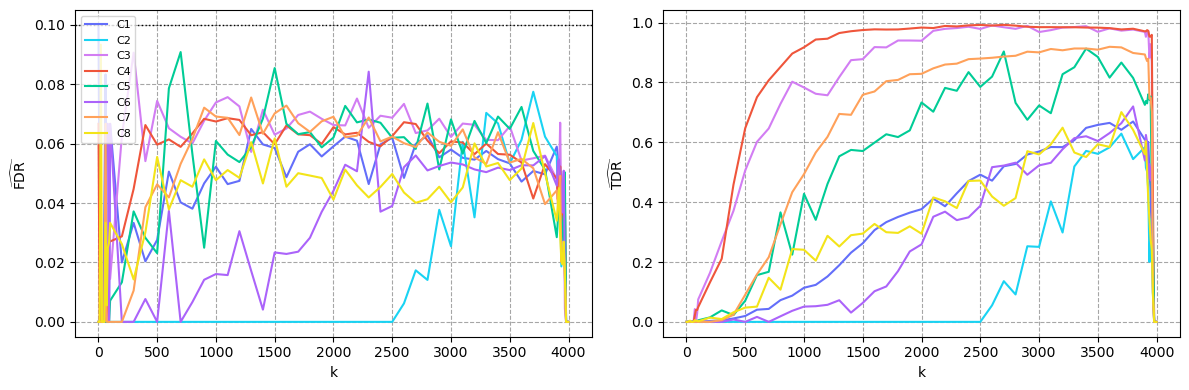

In [10]:
m1 = 300
m0 = 700
level = 0.1

n = 4000
runs = 10
k_values = np.unique(np.concatenate([
    np.arange(1, 101, 10),
    np.arange(100, 3901, 100),
    np.arange(3909, 4001, 10),
])).astype(int)

classifiers = {
    "LogisticRegression": lambda _: LogisticRegression(max_iter=1000),
    "MLP": lambda _: MLPClassifier(max_iter=300),
    "ADACNN": lambda in_ch: ADACNNClassifier(in_channels=in_ch, epochs=10, lr=1e-3, batch_size=128),
    "CNN": lambda in_ch: CNNClassifier(in_channels=in_ch),
    "ResNet": lambda in_ch: ResNetClassifier(in_channels=in_ch),
    "PCA_Logistic": lambda _: Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.8, svd_solver='full')),
        ("logistic", LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)),
    ]),
    "RandomForest": lambda _: RandomForestClassifier(max_depth=10),
    "AdaBoost": lambda _: AdaBoostClassifier(),
}

metrics = {name: {"fdp": [], "tdp": []} for name in classifiers}

for k in k_values:
    fdp_runs = {name: [] for name in classifiers}
    tdp_runs = {name: [] for name in classifiers}

    for i in range(runs):
        seed = BASE_SEED + i
        set_all_seeds(seed)
        rng = np.random.default_rng(seed)

        test_idx = rng.choice(len(inlr), replace=False, size=m0)
        test0 = inlr[test_idx].numpy() if torch.is_tensor(inlr) else inlr[test_idx]
        test1_idx = rng.choice(len(outlr), replace=False, size=m1)
        test1 = outlr[test1_idx].numpy() if torch.is_tensor(outlr) else outlr[test1_idx]
        x = np.concatenate([test0, test1])
        remaining_idx = np.setdiff1d(np.arange(len(inlr)), test_idx)
        rng.shuffle(remaining_idx)
        remaining_idx = remaining_idx[:n]
        xnull = inlr[remaining_idx].numpy() if torch.is_tensor(inlr) else inlr[remaining_idx]
        true_labels = np.concatenate([np.zeros(m0), np.ones(m1)])

        if dataset_name == 'mnist' or dataset_name == 'fashion_mnist':
            xnull_flatten = xnull.reshape(xnull.shape[0], -1)
            x_flatten = x.reshape(x.shape[0], -1)
            x_cnn = x.reshape(x.shape[0], 1, x.shape[1], x.shape[2])
            xnull_cnn = xnull.reshape(xnull.shape[0], 1, xnull.shape[1], xnull.shape[2])
        elif dataset_name == 'creditcard':
            xnull_flatten = xnull
            x_flatten = x
            x_cnn = None
            xnull_cnn = None
        elif dataset_name == 'ChestMNIST' or dataset_name == "OCTMNIST":
            xnull_flatten = xnull.reshape(xnull.shape[0], -1)
            x_flatten = x.reshape(x.shape[0], -1)
            x_cnn = x
            xnull_cnn = xnull
        elif dataset_name == 'DogsVsCats':
            xnull_flatten = xnull.reshape(xnull.shape[0], -1)
            x_flatten = x.reshape(x.shape[0], -1)
            x_cnn = x.permute(0, 3, 1, 2) if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
            xnull_cnn = xnull.permute(0, 3, 1, 2) if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32).permute(0, 3, 1, 2)
        elif dataset_name == 'DermaMNIST' or dataset_name == 'BloodMNIST':
            xnull_flatten = xnull.reshape(xnull.shape[0], -1)
            x_flatten = x.reshape(x.shape[0], -1)
            x_cnn = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
            xnull_cnn = xnull if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32)

        for name, build in classifiers.items():
            if name in {"ADACNN", "CNN", "ResNet"}:
                model = build(x_cnn.shape[1])
                proc = AdaDetectERM(scoring_fn=model, split_size=k / n)
                rejection_set = proc.apply(x_cnn, level, xnull_cnn)
            else:
                model = build(None)
                proc = AdaDetectERM(scoring_fn=model, split_size=k / n)
                rejection_set = proc.apply(x_flatten, level, xnull_flatten)

            fdp, tdp = get_fdp(true_labels, rejection_set)
            fdp_runs[name].append(fdp)
            tdp_runs[name].append(tdp)
    print(f"Completed k={k} (k/n={k/n:.2f})")
    for name in classifiers:
        metrics[name]["fdp"].append((np.mean(fdp_runs[name]), np.std(fdp_runs[name])))
        metrics[name]["tdp"].append((np.mean(tdp_runs[name]), np.std(tdp_runs[name])))

colors = {
    "ADACNN": "#d27df3",
    "CNN": "#ef553b",
    "ResNet": "#00cc96",
    "MLP": "#19d3f3",
    "LogisticRegression": "#636efa",
    "PCA_Logistic": "#ab63fa",
    "RandomForest": "#ffa15a",
    "AdaBoost": "#f3e419",
}

label_map = {
    "Logistic": "C1",
    "LogisticRegression": "C1",
    "MLP": "C2",
    "ADACNN": "C3",
    "CNN": "C4",
    "ResNet": "C5",
    "PCA_Logistic": "C6",
    "RandomForest": "C7",
    "AdaBoost": "C8",
}

output_dir = Path("pictures_for_monday")
output_dir.mkdir(parents=True, exist_ok=True)

fig, (ax_fdp, ax_tdp) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for name in classifiers:
    means = [m for m, _ in metrics[name]["fdp"]]
    stds = [s for _, s in metrics[name]["fdp"]]
    line = ax_fdp.plot(k_values, means, label=label_map.get(name, name), color=colors.get(name))[0]
    # ax_fdp.fill_between(
    #     k_values,
    #     np.array(means) - np.array(stds),
    #     np.array(means) + np.array(stds),
    #     color=line.get_color(),
    #     alpha=0.15
    # )

ax_fdp.axhline(level, color="black", linestyle=":", linewidth=1)
ax_fdp.set_xlabel("k")
ax_fdp.set_ylabel(r"$\widehat{\text{FDR}}$")
ax_fdp.set_axisbelow(True)
ax_fdp.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

ax_fdp.legend(loc="upper left", fontsize=8)

for name in classifiers:
    means = [m for m, _ in metrics[name]["tdp"]]
    stds = [s for _, s in metrics[name]["tdp"]]
    line = ax_tdp.plot(k_values, means, label=label_map.get(name, name), color=colors.get(name))[0]
    # ax_tdp.fill_between(
    #     k_values,
    #     np.array(means) - np.array(stds),
    #     np.array(means) + np.array(stds),
    #     color=line.get_color(),
    #     alpha=0.15
    # )

ax_tdp.set_xlabel("k")
ax_tdp.set_ylabel(r"$\widehat{\text{TDR}}$")
ax_tdp.set_axisbelow(True)
ax_tdp.grid(True, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
fig.tight_layout()
fig_path = output_dir / f"fdr_tdr_vs_k_ratio_{dataset_name}.pdf"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to {fig_path}")

plt.show()

## Ændring af parameretre - \lambda

In [ ]:
# m1 = 950
# m0 = 50
# level = 0.1
# k= 3000
# n = 4000
# runs = 5
# lamda_list = np.arange(0.05, 1.0 , 0.05)

# classifiers = {
#     "ADACNN": lambda in_ch: ADACNNClassifier(in_channels=in_ch, epochs=10, lr=1e-3, batch_size=128),
#     "CNN": lambda in_ch: CNNClassifier(in_channels=in_ch),
#     "ResNet": lambda in_ch: ResNetClassifier(in_channels=in_ch),
#     "MLP": lambda _: MLPClassifier(max_iter=300),
#     "LogisticRegression": lambda _: LogisticRegression(max_iter=1000),
#     "PCA_Logistic": lambda _: Pipeline([
#         ("scale", StandardScaler()),
#         ("pca", PCA(n_components=0.8, svd_solver='full')),
#         ("logistic", LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)),
#     ]),
# }

# metrics = {name: {"fdp": [], "tdp": []} for name in classifiers}

# for lamda in lamda_list:
#     fdp_runs = {name: [] for name in classifiers}
#     tdp_runs = {name: [] for name in classifiers}

#     for i in range(runs):
#         seed = BASE_SEED + i
#         set_all_seeds(seed)
#         rng = np.random.default_rng(seed)

#         test_idx = rng.choice(len(inlr), replace=False, size=m0)
#         test0 = inlr[test_idx].numpy() if torch.is_tensor(inlr) else inlr[test_idx]
#         test1_idx = rng.choice(len(outlr), replace=False, size=m1)
#         test1 = outlr[test1_idx].numpy() if torch.is_tensor(outlr) else outlr[test1_idx]
#         x = np.concatenate([test0, test1])
#         remaining_idx = np.setdiff1d(np.arange(len(inlr)), test_idx)
#         rng.shuffle(remaining_idx)
#         remaining_idx = remaining_idx[:n]
#         xnull = inlr[remaining_idx].numpy() if torch.is_tensor(inlr) else inlr[remaining_idx]
#         true_labels = np.concatenate([np.zeros(m0), np.ones(m1)])

#         if dataset_name == 'mnist' or dataset_name == 'fashion_mnist':
#             xnull_flatten = xnull.reshape(xnull.shape[0], -1)
#             x_flatten = x.reshape(x.shape[0], -1)
#             x_cnn = x.reshape(x.shape[0], 1, x.shape[1], x.shape[2])
#             xnull_cnn = xnull.reshape(xnull.shape[0], 1, xnull.shape[1], xnull.shape[2])
#         elif dataset_name == 'creditcard':
#             xnull_flatten = xnull
#             x_flatten = x
#             x_cnn = None
#             xnull_cnn = None
#         elif dataset_name == 'ChestMNIST' or dataset_name == "OCTMNIST":
#             xnull_flatten = xnull.reshape(xnull.shape[0], -1)
#             x_flatten = x.reshape(x.shape[0], -1)
#             x_cnn = x
#             xnull_cnn = xnull
#         elif dataset_name == 'DogsVsCats':
#             xnull_flatten = xnull.reshape(xnull.shape[0], -1)
#             x_flatten = x.reshape(x.shape[0], -1)
#             x_cnn = x.permute(0, 3, 1, 2) if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
#             xnull_cnn = xnull.permute(0, 3, 1, 2) if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32).permute(0, 3, 1, 2)
#         elif dataset_name == 'DermaMNIST' or dataset_name == 'BloodMNIST':
#             xnull_flatten = xnull.reshape(xnull.shape[0], -1)
#             x_flatten = x.reshape(x.shape[0], -1)
#             x_cnn = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
#             xnull_cnn = xnull if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32)

#         for name, build in classifiers.items():
#             if name in {"ADACNN", "CNN", "ResNet"}:
#                 model = build(x_cnn.shape[1])
#                 proc = AdaDetectERM(scoring_fn=model,correction_type="storey", split_size=k / n,storey_threshold=lamda)
#                 rejection_set = proc.apply(x_cnn, level, xnull_cnn)
#             else:
#                 model = build(None)
#                 proc = AdaDetectERM(scoring_fn=model, correction_type="storey", split_size=k / n,storey_threshold=lamda)
#                 rejection_set = proc.apply(x_flatten, level, xnull_flatten)

#             fdp, tdp = get_fdp(true_labels, rejection_set)
#             fdp_runs[name].append(fdp)
#             tdp_runs[name].append(tdp)
#     print(f"Completed lambda={lamda:.2f}")
#     for name in classifiers:
#         metrics[name]["fdp"].append((np.mean(fdp_runs[name]), np.std(fdp_runs[name])))
#         metrics[name]["tdp"].append((np.mean(tdp_runs[name]), np.std(tdp_runs[name])))

# colors = {
#     "ADACNN": "#d27df3",
#     "CNN": "#ef553b",
#     "ResNet": "#00cc96",
#     "MLP": "#19d3f3",
#     "LogisticRegression": "#636efa",
#     "PCA_Logistic": "#ab63fa",
# }

# label_map = {
#     "Logistic": "C1",
#     "LogisticRegression": "C1",
#     "MLP": "C2",
#     "ADACNN": "C3",
#     "CNN": "C4",
#     "ResNet": "C5",
#     "PCA_Logistic": "C6",
#     "RandomForest": "C7",
#     "AdaBoost": "C8",
# }

# output_dir = Path("pictures_for_monday")
# output_dir.mkdir(parents=True, exist_ok=True)

# fig_fdp, ax_fdp = plt.subplots(figsize=(6, 4))
# for name in classifiers:
#     means = [m for m, _ in metrics[name]["fdp"]]
#     stds = [s for _, s in metrics[name]["fdp"]]
#     line = ax_fdp.plot(lamda_list, means, label=label_map.get(name, name), color=colors.get(name))[0]
#     # ax_fdp.fill_between(
#     #     lamda_list,
#     #     np.array(means) - np.array(stds),
#     #     np.array(means) + np.array(stds),
#     #     color=line.get_color(),
#     #     alpha=0.15
#     # )

# ax_fdp.axhline(level, color="black", linestyle=":", linewidth=1)
# ax_fdp.set_xlabel("lambda")
# ax_fdp.set_ylabel("FDP")
# ax_fdp.set_title(f"m = {m0 + m1}, m1 = {m1}, level={level}")
# ax_fdp.legend(loc="upper right", fontsize=8)
# fig_fdp.tight_layout()
# fig_path_fdp = output_dir / f"fdp_vs_lambda_{dataset_name}_fdp.pdf"
# fig_fdp.savefig(fig_path_fdp, dpi=300, bbox_inches="tight")
# print(f"Saved figure to {fig_path_fdp}")

# fig_tdp, ax_tdp = plt.subplots(figsize=(6, 4))
# for name in classifiers:
#     means = [m for m, _ in metrics[name]["tdp"]]
#     stds = [s for _, s in metrics[name]["tdp"]]
#     line = ax_tdp.plot(lamda_list, means, label=label_map.get(name, name), color=colors.get(name))[0]
#     # ax_tdp.fill_between(
#     #     lamda_list,
#     #     np.array(means) - np.array(stds),
#     #     np.array(means) + np.array(stds),
#     #     color=line.get_color(),
#     #     alpha=0.15
#     # )

# ax_tdp.set_xlabel("lambda")
# ax_tdp.set_ylabel("TDP")
# ax_tdp.set_title(f"m = {m0 + m1}, m1 = {m1}, level={level}")
# ax_tdp.legend(loc="lower right", fontsize=8)
# fig_tdp.tight_layout()
# fig_path_tdp = output_dir / f"tdp_vs_lambda_{dataset_name}_tdp.pdf"
# fig_tdp.savefig(fig_path_tdp, dpi=300, bbox_inches="tight")
# print(f"Saved figure to {fig_path_tdp}")

# plt.show()